<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial03/Tutorial03_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Phase 1: The Base PyTorch Conversion & Setup**

MNIST_MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

Starting training on cuda...
Epoch [1/10] | Train Loss: 0.3237, Train Acc: 0.9075 | Val Loss: 0.1952, Val Acc: 0.9392
Epoch [2/10] | Train Loss: 0.1373, Train Acc: 0.9580 | Val Loss: 0.1349, Val Acc: 0.9567
Epoch [3/10] | Train Loss: 0.0927, Train Acc: 0.9710 | Val Loss: 0.0981, Val Acc: 0.9689
Epoch [4/10] | Train Loss: 0.0683, Train Acc: 0.9780 | Val Loss: 0.0940, Val Acc: 0.9703
Epoch [5/10] | Train Loss: 0.0534, Train Acc: 0.9829 | Val Loss: 0.1168, Val Acc: 0.9649
Epoch [6/10] | Train Loss: 0.0427, Train Acc: 0.9867 | Val Loss: 0.0984, Val Acc: 0.9699
Epoch [7/10] | Train Loss: 0.0350, Train Acc: 0.9885 | Val Loss: 0.0925, Val Acc: 0.9716
Epoch [8/10] | Train Loss: 0.0269, Train Acc: 0.9913 | Val Loss: 0.11

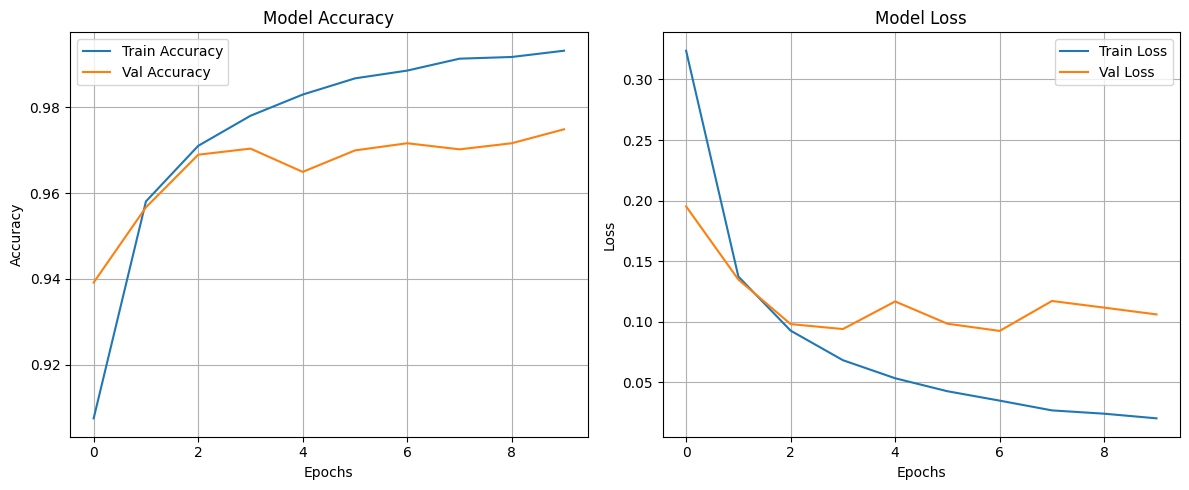


Final Test Accuracy: 0.9745
Results saved to ann_results/


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. Setup Directory
# ==========================================
output_dir = "ann_results"
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 1. Loading and Preprocessing the Dataset
# ==========================================
# transforms.ToTensor() converts images to PyTorch tensors and scales pixels to [0, 1]
transform = transforms.ToTensor()

# Download and load the MNIST training and test datasets
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create a 20% validation split (simulating Keras validation_split=0.2)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for batching (batch_size=32 as per tutorial)
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================
# 2. Building the Neural Network Model
# ==========================================
class MNIST_MLP(nn.Module):
    def __init__(self):
        super(MNIST_MLP, self).__init__()
        # Flatten 28x28 images to a 1D vector of 784 features
        self.flatten = nn.Flatten()

        # Hidden layer 1: 128 neurons, ReLU activation
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()

        # Hidden layer 2: 64 neurons, ReLU activation
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        # Output layer: 10 neurons (for digits 0-9)
        self.fc3 = nn.Linear(64, 10)
        # Note: No Softmax here; PyTorch's CrossEntropyLoss handles it internally

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

# Automatically use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNIST_MLP().to(device)
print(model)

# ==========================================
# 3. Compiling the Model (Loss and Optimizer)
# ==========================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# ==========================================
# 4. Training and Validation Loop
# ==========================================
epochs = 10

# Tracking metrics for plotting
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"\nStarting training on {device}...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

# ==========================================
# 5. Plotting and Saving Curves
# ==========================================
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'base_model_curves.png'))
plt.show()

# ==========================================
# 6. Evaluate on Test Set and Save Summary
# ==========================================
model.eval()
correct_test, total_test = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_accuracy = correct_test / total_test
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")

# Append results to summary.txt
with open(os.path.join(output_dir, 'summary.txt'), 'a') as f:
    f.write("============================================================\n")
    f.write("BASE MODEL (PyTorch Conversion)\n")
    f.write("============================================================\n")
    f.write("Architecture: 784 -> 128 (ReLU) -> 64 (ReLU) -> 10\n")
    f.write("Optimizer: Adam | Loss: CrossEntropy\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n\n")

print(f"Results saved to {output_dir}/")

# **Phase 2: Architecture & Optimizer Experiments**


Running Architecture Experiments (with Adam)...
Training Base (ReLU)...
Training Tanh...
Training Deeper...

Running Optimizer Experiments (on Base Model)...
Training Base Model with SGD...
Training Base Model with RMSprop...
Training Base Model with Adam...


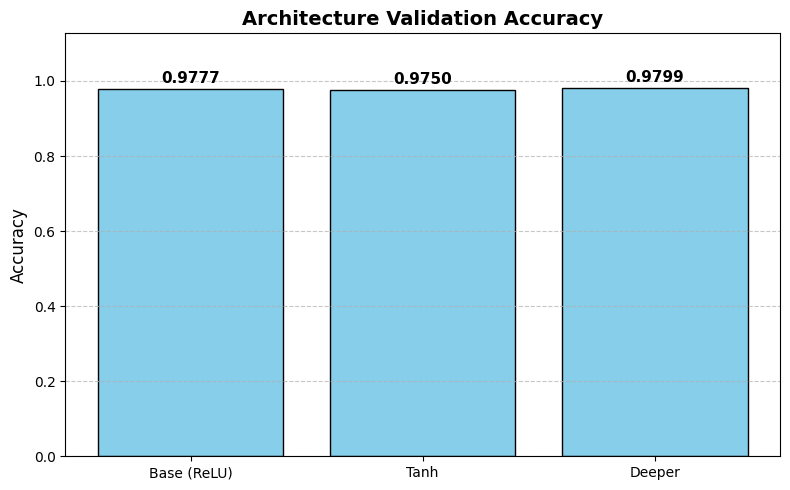

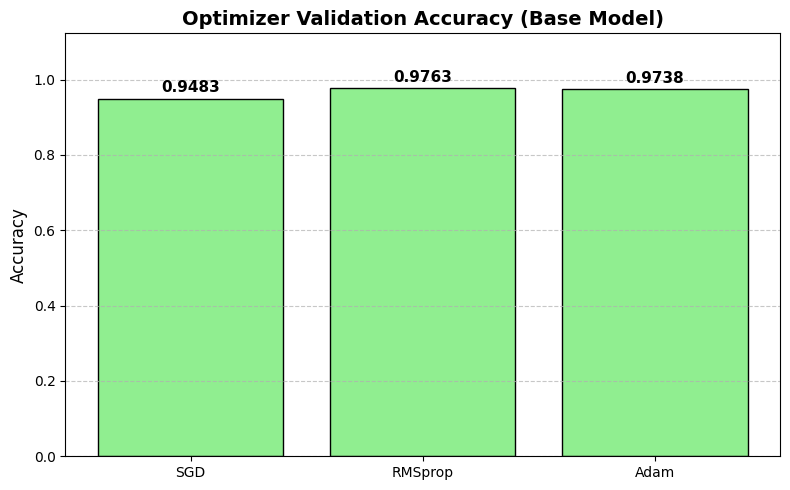

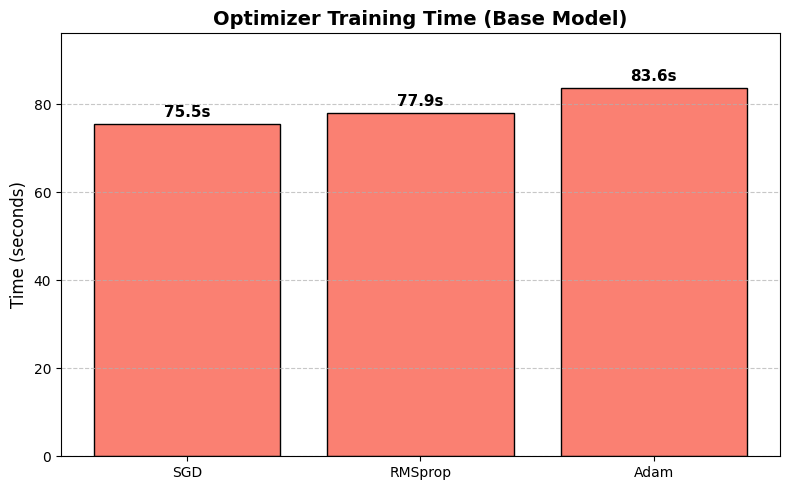

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import os

# Ensure directory exists
output_dir = "ann_results"
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 1. Define the Different Architectures
# ==========================================
class BaseModel(nn.Module):
    def __init__(self):
        super(BaseModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc3(self.relu2(self.fc2(self.relu1(self.fc1(x)))))

class TanhModel(nn.Module):
    def __init__(self):
        super(TanhModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.tanh1 = nn.Tanh()
        self.fc2 = nn.Linear(128, 64)
        self.tanh2 = nn.Tanh()
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc3(self.tanh2(self.fc2(self.tanh1(self.fc1(x)))))

class DeeperModel(nn.Module):
    def __init__(self):
        super(DeeperModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 64)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        return self.fc4(x)

# ==========================================
# 2. Reusable Training Helper Function
# ==========================================
def train_and_evaluate(model_class, optimizer_class, lr=0.001, epochs=10):
    model = model_class().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_class(model.parameters(), lr=lr)

    start_time = time.time()

    # Train
    model.train()
    for epoch in range(epochs):
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()

    # Validate
    model.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    end_time = time.time()
    val_acc = correct_val / total_val
    training_time = end_time - start_time

    return val_acc, training_time

# ==========================================
# 3. Run Experiments
# ==========================================
print("Running Architecture Experiments (with Adam)...")
arch_results = {}
arch_models = {'Base (ReLU)': BaseModel, 'Tanh': TanhModel, 'Deeper': DeeperModel}

for name, MClass in arch_models.items():
    print(f"Training {name}...")
    acc, t = train_and_evaluate(MClass, optim.Adam)
    arch_results[name] = acc

print("\nRunning Optimizer Experiments (on Base Model)...")
opt_results_acc = {}
opt_results_time = {}
# Note: SGD generally requires a higher learning rate (0.01) to compete with Adam/RMSprop (0.001)
optimizers = {'SGD': (optim.SGD, 0.01), 'RMSprop': (optim.RMSprop, 0.001), 'Adam': (optim.Adam, 0.001)}

for name, (OptClass, lr) in optimizers.items():
    print(f"Training Base Model with {name}...")
    acc, t = train_and_evaluate(BaseModel, OptClass, lr=lr)
    opt_results_acc[name] = acc
    opt_results_time[name] = t

# ==========================================
# 4. Generate and Save Visualizations
# ==========================================
def plot_bar(data_dict, title, ylabel, filename, color):
    names = list(data_dict.keys())
    values = list(data_dict.values())

    plt.figure(figsize=(8, 5))
    bars = plt.bar(names, values, color=color, edgecolor='black')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add data labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        label = f"{yval:.4f}" if "Accuracy" in ylabel else f"{yval:.1f}s"
        plt.text(bar.get_x() + bar.get_width()/2, yval + (0.01 if "Accuracy" in ylabel else 1),
                 label, ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.ylim(0, max(values) * 1.15) # Add headroom for labels
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, filename))
    plt.show()

# Plot 1: Architecture Accuracies
plot_bar(arch_results, 'Architecture Validation Accuracy', 'Accuracy', 'architecture_acc_bar.png', 'skyblue')

# Plot 2: Optimizer Accuracies
plot_bar(opt_results_acc, 'Optimizer Validation Accuracy (Base Model)', 'Accuracy', 'optimizer_acc_bar.png', 'lightgreen')

# Plot 3: Optimizer Times
plot_bar(opt_results_time, 'Optimizer Training Time (Base Model)', 'Time (seconds)', 'optimizer_time_bar.png', 'salmon')

# ==========================================
# 5. Save Results to summary.txt
# ==========================================
with open(os.path.join(output_dir, 'summary.txt'), 'a') as f:
    f.write("\n============================================================\n")
    f.write("PHASE 2: ARCHITECTURE & OPTIMIZER EXPERIMENTS\n")
    f.write("============================================================\n")

    f.write("1. Architecture Performance (Optimizer: Adam)\n")
    f.write("-" * 45 + "\n")
    for name, acc in arch_results.items():
        f.write(f"{name:<15} | Validation Accuracy: {acc:.4f}\n")

    f.write("\n2. Optimizer Performance (Architecture: Base ReLU)\n")
    f.write("-" * 55 + "\n")
    for name in opt_results_acc.keys():
        f.write(f"{name:<10} | Acc: {opt_results_acc[name]:.4f} | Time: {opt_results_time[name]:.2f}s\n")
    f.write("\n")

# **Phase 3: Regularization & Confusion Matrix**

Training Regularized Model on cuda...
Epoch [1/50] | Train Loss: 0.4025, Train Acc: 0.8782 | Val Loss: 0.2104, Val Acc: 0.9363
Epoch [2/50] | Train Loss: 0.1873, Train Acc: 0.9444 | Val Loss: 0.1384, Val Acc: 0.9577
Epoch [3/50] | Train Loss: 0.1452, Train Acc: 0.9566 | Val Loss: 0.1212, Val Acc: 0.9619
Epoch [4/50] | Train Loss: 0.1191, Train Acc: 0.9637 | Val Loss: 0.1099, Val Acc: 0.9665
Epoch [5/50] | Train Loss: 0.1080, Train Acc: 0.9676 | Val Loss: 0.1014, Val Acc: 0.9698
Epoch [6/50] | Train Loss: 0.0995, Train Acc: 0.9690 | Val Loss: 0.1027, Val Acc: 0.9703
Epoch [7/50] | Train Loss: 0.0896, Train Acc: 0.9713 | Val Loss: 0.0941, Val Acc: 0.9741
Epoch [8/50] | Train Loss: 0.0844, Train Acc: 0.9740 | Val Loss: 0.1047, Val Acc: 0.9710
Epoch [9/50] | Train Loss: 0.0801, Train Acc: 0.9752 | Val Loss: 0.0887, Val Acc: 0.9752
Epoch [10/50] | Train Loss: 0.0754, Train Acc: 0.9759 | Val Loss: 0.0934, Val Acc: 0.9735
Epoch [11/50] | Train Loss: 0.0729, Train Acc: 0.9767 | Val Loss: 0.094

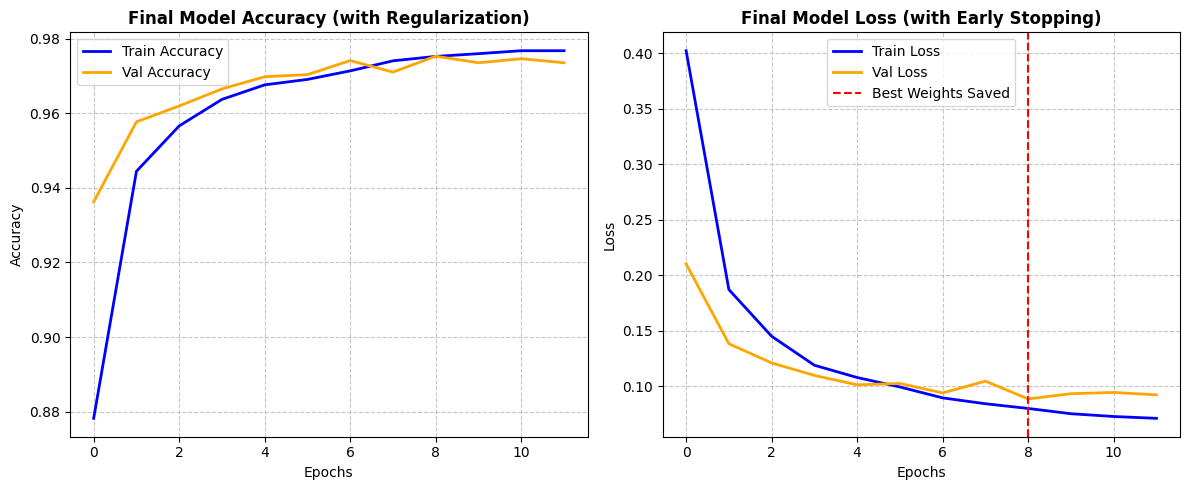


Evaluating Final Model on Test Set...


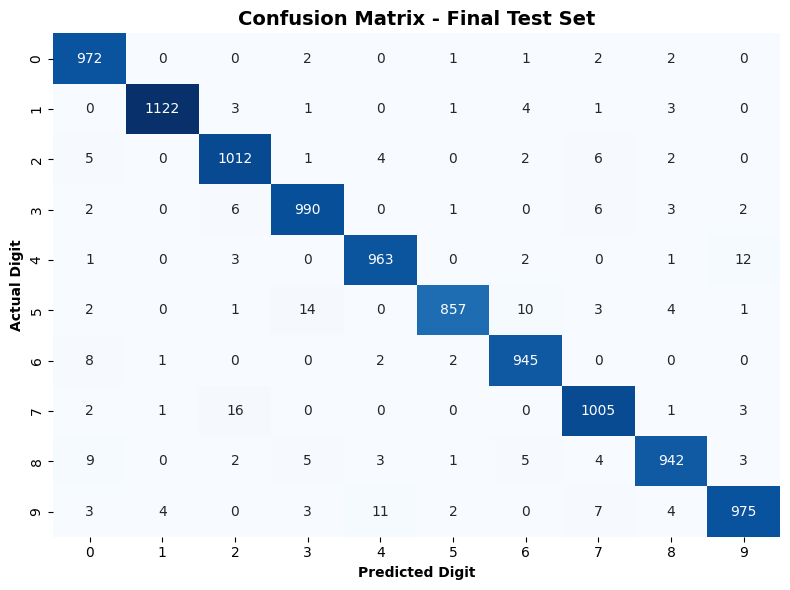

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import os
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Ensure directory exists
output_dir = "ann_results"
os.makedirs(output_dir, exist_ok=True)

# (Optional: Re-setup DataLoaders if running in a fresh kernel)
transform = transforms.ToTensor()
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_size = int(0.8 * len(full_train_dataset))
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, len(full_train_dataset) - train_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. Define Model with Dropout
# ==========================================
class RegularizedModel(nn.Module):
    def __init__(self):
        super(RegularizedModel, self).__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.2) # 20% Dropout

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.2) # 20% Dropout

        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        return self.fc3(x)

model = RegularizedModel().to(device)

# ==========================================
# 2. Loss and Optimizer (with L2 Regularization)
# ==========================================
criterion = nn.CrossEntropyLoss()
# 'weight_decay=1e-4' is PyTorch's implementation of L2 Regularization
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ==========================================
# 3. Training Loop with Early Stopping
# ==========================================
max_epochs = 50 # Set high, early stopping will halt it
patience = 3

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())
stopped_epoch = max_epochs

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"Training Regularized Model on {device}...")

for epoch in range(max_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    # --- EARLY STOPPING LOGIC ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered! Validation loss hasn't improved for {patience} epochs.")
            stopped_epoch = epoch + 1
            break

# Load the weights from the best epoch back into the model
model.load_state_dict(best_model_wts)

# ==========================================
# 4. Generate Final Training Curves
# ==========================================
plt.figure(figsize=(12, 5))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history['val_acc'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Final Model Accuracy (with Regularization)', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history['val_loss'], label='Val Loss', color='orange', linewidth=2)
plt.axvline(x=stopped_epoch - patience - 1, color='red', linestyle='--', label='Best Weights Saved')
plt.title('Final Model Loss (with Early Stopping)', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'final_model_curves.png'))
plt.show()

# ==========================================
# 5. Evaluate on Test Set & Confusion Matrix
# ==========================================
print("\nEvaluating Final Model on Test Set...")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Final Metrics
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
class_report = classification_report(all_labels, all_preds, digits=4)

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Final Test Set', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Digit', fontweight='bold')
plt.ylabel('Actual Digit', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
plt.show()

# ==========================================
# 6. Append to Summary File
# ==========================================
with open(os.path.join(output_dir, 'summary.txt'), 'a') as f:
    f.write("\n============================================================\n")
    f.write("PHASE 3: REGULARIZATION & FINAL EVALUATION\n")
    f.write("============================================================\n")
    f.write(f"Techniques Applied: Dropout (0.2), L2 Regularization (1e-4), Early Stopping\n")
    f.write(f"Training stopped at Epoch : {stopped_epoch}\n")
    f.write(f"Best Weights loaded from  : Epoch {stopped_epoch - patience}\n")
    f.write(f"Final Test Accuracy       : {test_acc:.4f}\n\n")
    f.write("Scikit-Learn Classification Report:\n")
    f.write(class_report)
    f.write("\n============================================================\n")


# **Phase 4: Predictions & Error Analysis**

Standard Predictions grid saved to: ann_results/correct_predictions_grid.png


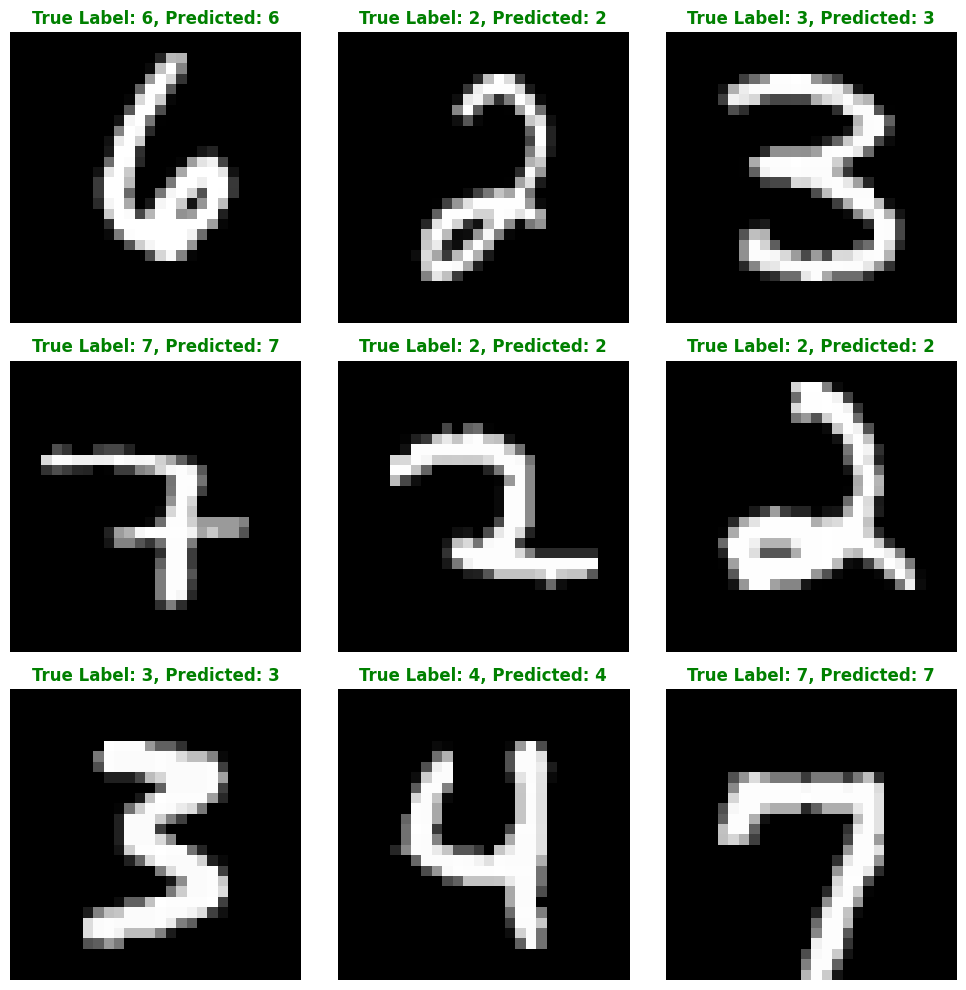

Misclassified Predictions grid saved to: ann_results/misclassified_grid.png


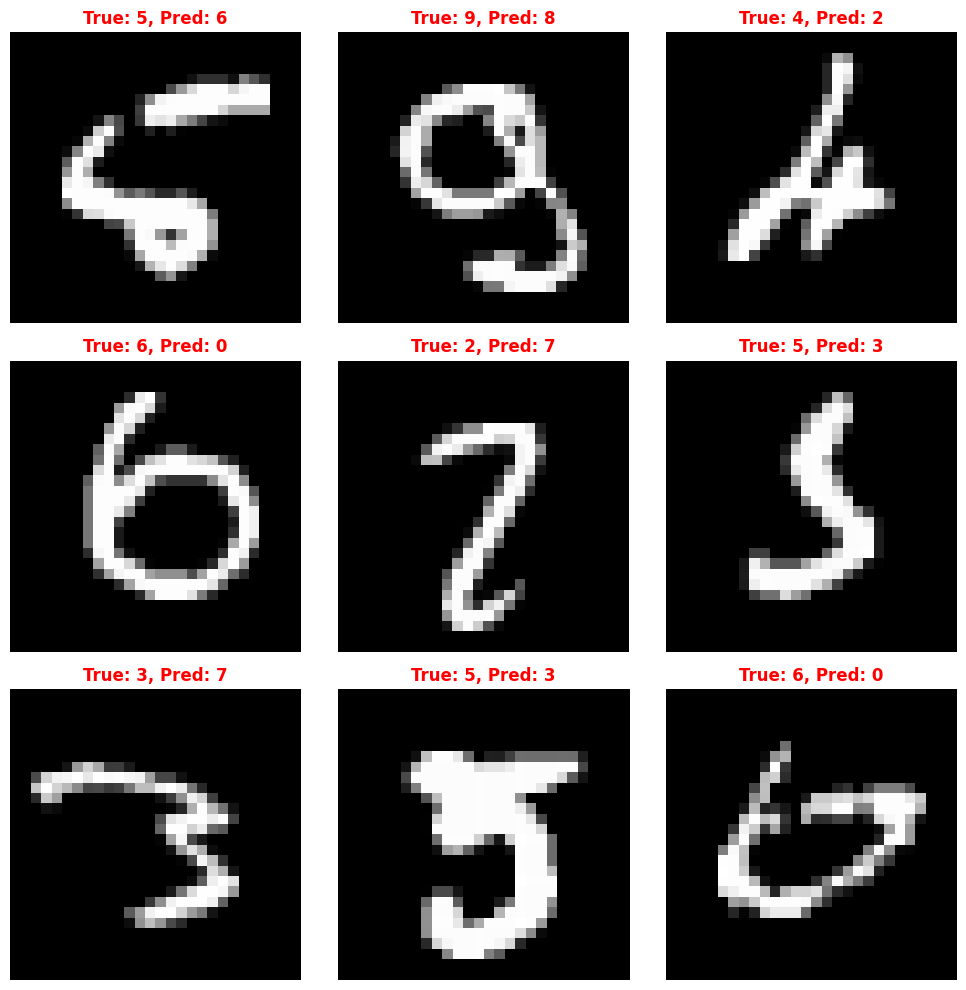

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure directory exists (if running independently)
output_dir = "ann_results"
os.makedirs(output_dir, exist_ok=True)

# ==========================================
# 1. Collect All Test Set Predictions
# ==========================================
print("Collecting predictions for visual analysis...")
model.eval()

all_images = []
all_labels = []
all_preds = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs_device = inputs.to(device)
        outputs = model(inputs_device)
        _, predicted = torch.max(outputs.data, 1)

        # Move back to CPU and convert to numpy for matplotlib
        all_images.extend(inputs.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.cpu().numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# ==========================================
# 2. Grid 1: Standard Predictions (Random/First 9)
# ==========================================
plt.figure(figsize=(10, 10))
# Let's pick 9 random indices to show a variety
np.random.seed(42) # For reproducible random samples
random_indices = np.random.choice(len(all_labels), 9, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)

    # Squeeze removes the channel dimension (1, 28, 28) -> (28, 28)
    img = all_images[idx].squeeze()
    true_label = all_labels[idx]
    pred_label = all_preds[idx]

    plt.imshow(img, cmap='gray')

    # Color title green if correct, red if incorrect
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True Label: {true_label}, Predicted: {pred_label}", color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
grid1_path = os.path.join(output_dir, 'correct_predictions_grid.png')
plt.savefig(grid1_path)
print(f"Standard Predictions grid saved to: {grid1_path}")
plt.show()

# ==========================================
# 3. Grid 2: Misclassified Images (Error Analysis)
# ==========================================
# Find indices where the predicted label does NOT match the true label
misclassified_indices = np.where(all_labels != all_preds)[0]

plt.figure(figsize=(10, 10))
# Take the first 9 misclassified images
for i, idx in enumerate(misclassified_indices[:9]):
    plt.subplot(3, 3, i + 1)

    img = all_images[idx].squeeze()
    true_label = all_labels[idx]
    pred_label = all_preds[idx]

    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}, Pred: {pred_label}", color='red', fontweight='bold')
    plt.axis('off')

plt.tight_layout()
grid2_path = os.path.join(output_dir, 'misclassified_grid.png')
plt.savefig(grid2_path)
print(f"Misclassified Predictions grid saved to: {grid2_path}")
plt.show()
